In [1]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
import time
import io

# Load all results from previous notebooks
results_files = {
    'baseline': 'baseline_results.json',
    'chronos': 'chronos_results.json',
    'prophet': 'prophet_results.json',
    'garch': 'garch_results.json',
    'xgboost': 'xgboost_results.json',
    'classical': 'classical_results.json',
    'autogluon': 'autogluon_results.json',
    'conditional': 'conditional_results.json'
}

all_results = {}
for name, filepath in results_files.items():
    try:
        with open(filepath, 'r') as f:
            all_results[name] = json.load(f)
        print(f"✓ Loaded {name} results")
    except FileNotFoundError:
        print(f"✗ Missing {filepath}")
        all_results[name] = None

print(f"\nAll project results consolidated")

✓ Loaded baseline results
✓ Loaded chronos results
✓ Loaded prophet results
✓ Loaded garch results
✓ Loaded xgboost results
✓ Loaded classical results
✓ Loaded autogluon results
✓ Loaded conditional results

All project results consolidated


In [2]:
# Build the master comparison: every model × every pair × every metric

pairs = ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']

rows = []

for pair in pairs:
    # Naive baseline
    if all_results['baseline'] and pair in all_results['baseline']:
        b = all_results['baseline'][pair]
        rows.append({
            'pair': pair.upper(),
            'model': 'Naive (random walk)',
            'theil_u': 1.0,
            'direction_acc': 50.0,
            'mape_pct': b.get('mape', None),
            'category': 'baseline'
        })
    
    # Chronos
    if all_results['chronos'] and pair in all_results['chronos']:
        c = all_results['chronos'][pair]
        rows.append({
            'pair': pair.upper(),
            'model': 'Chronos-Bolt',
            'theil_u': c['theil_u'],
            'direction_acc': c['direction_accuracy'] * 100,
            'mape_pct': c.get('chronos_mape', None),
            'category': 'foundation_model'
        })
    
    # Prophet (basic)
    if all_results['prophet'] and pair in all_results['prophet']:
        p = all_results['prophet'][pair].get('basic', {})
        if p:
            rows.append({
                'pair': pair.upper(),
                'model': 'Prophet',
                'theil_u': p['theil_u'],
                'direction_acc': p['direction_accuracy'] * 100,
                'mape_pct': None,
                'category': 'classical'
            })
    
    # AutoARIMA
    if all_results['classical'] and 'arima' in all_results['classical']:
        if pair in all_results['classical']['arima']:
            a = all_results['classical']['arima'][pair]
            rows.append({
                'pair': pair.upper(),
                'model': 'AutoARIMA',
                'theil_u': a['theil_u'],
                'direction_acc': a['direction_accuracy'] * 100,
                'mape_pct': None,
                'category': 'classical'
            })
    
    # AutoETS
    if all_results['classical'] and 'ets' in all_results['classical']:
        if pair in all_results['classical']['ets']:
            e = all_results['classical']['ets'][pair]
            rows.append({
                'pair': pair.upper(),
                'model': 'AutoETS',
                'theil_u': e['theil_u'],
                'direction_acc': e['direction_accuracy'] * 100,
                'mape_pct': None,
                'category': 'classical'
            })
    
    # XGBoost
    if all_results['xgboost'] and pair in all_results['xgboost']:
        x = all_results['xgboost'][pair]
        rows.append({
            'pair': pair.upper(),
            'model': 'XGBoost',
            'theil_u': None,
            'direction_acc': x['direction_accuracy'] * 100,
            'mape_pct': None,
            'category': 'tabular_ml'
        })
    
    # AutoGluon (multi-step note)
    if all_results['autogluon'] and pair in all_results['autogluon']:
        ag = all_results['autogluon'][pair]
        rows.append({
            'pair': pair.upper(),
            'model': f"AutoGluon ({ag['model']})",
            'theil_u': ag['theil_u'],
            'direction_acc': ag['direction_accuracy'] * 100,
            'mape_pct': ag.get('mape_pct', None),
            'category': 'automl'
        })
    
    # GARCH (volatility — different metric)
    if all_results['garch'] and pair in all_results['garch']:
        g = all_results['garch'][pair]
        rows.append({
            'pair': pair.upper(),
            'model': 'GARCH (volatility)',
            'theil_u': g['theil_u_vs_naive'],
            'direction_acc': None,
            'mape_pct': None,
            'category': 'volatility'
        })

master_df = pd.DataFrame(rows)

print("=== Master Model Comparison ===\n")
for pair in ['USD_INR', 'USD_EUR', 'USD_GBP', 'USD_MXN', 'USD_PHP']:
    print(f"\n{pair}:")
    subset = master_df[master_df['pair'] == pair][['model', 'theil_u', 'direction_acc']]
    print(subset.round(3).to_string(index=False))

=== Master Model Comparison ===


USD_INR:
                       model  theil_u  direction_acc
         Naive (random walk)    1.000         50.000
                Chronos-Bolt    1.045         63.333
                     Prophet    2.071         41.667
                   AutoARIMA    0.998         61.667
                     AutoETS    1.005         53.333
                     XGBoost      NaN         51.667
AutoGluon (RecursiveTabular)    3.718         33.333
          GARCH (volatility)    0.714            NaN

USD_EUR:
                       model  theil_u  direction_acc
         Naive (random walk)    1.000         50.000
                Chronos-Bolt    1.037         46.667
                     Prophet    3.113         53.333
                   AutoARIMA    1.000         46.667
                     AutoETS    0.995         61.667
                     XGBoost      NaN         56.667
AutoGluon (WeightedEnsemble)    3.726         43.333
          GARCH (volatility)    0.699         

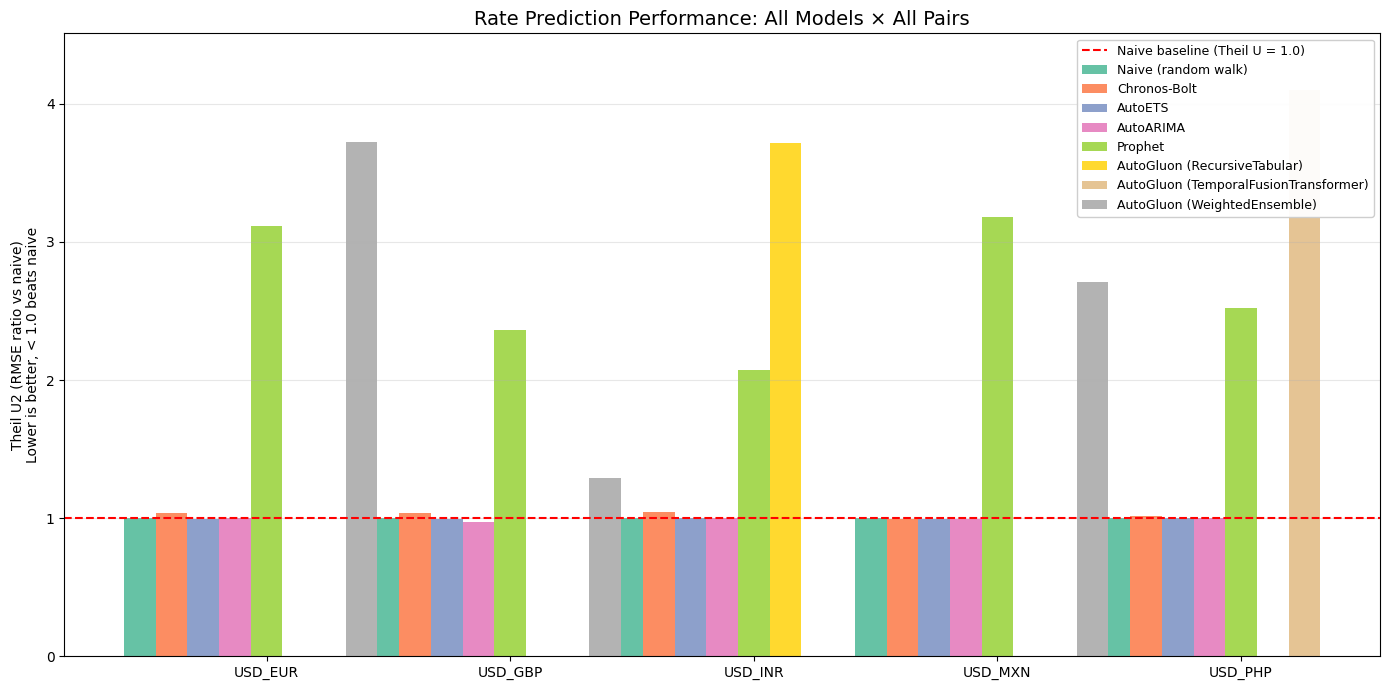

Note: bars above red line (Theil U = 1.0) lose to naive baseline.
Most models either tie naive (Theil ~1.0) or lose to it (>1.0).


In [3]:
# Filter to rate-prediction models only (exclude volatility GARCH which has different metric)
rate_models = master_df[master_df['category'].isin(['baseline', 'foundation_model', 'classical', 'automl'])].copy()
rate_models = rate_models.dropna(subset=['theil_u'])

# Pivot for plotting
pivot_theil = rate_models.pivot_table(index='model', columns='pair', values='theil_u', aggfunc='first')

# Order models logically
model_order = ['Naive (random walk)', 'Chronos-Bolt', 'AutoETS', 'AutoARIMA', 'Prophet']
ag_models = [m for m in pivot_theil.index if 'AutoGluon' in m]
model_order = [m for m in model_order if m in pivot_theil.index] + ag_models

pivot_theil = pivot_theil.reindex([m for m in model_order if m in pivot_theil.index])

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(pivot_theil.columns))
width = 0.13
colors = plt.cm.Set2(np.linspace(0, 1, len(pivot_theil)))

for i, (model, row) in enumerate(pivot_theil.iterrows()):
    offset = (i - len(pivot_theil)/2) * width
    bars = ax.bar(x + offset, row.values, width, label=model, color=colors[i])

ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Naive baseline (Theil U = 1.0)')
ax.set_xticks(x)
ax.set_xticklabels(pivot_theil.columns)
ax.set_ylabel('Theil U2 (RMSE ratio vs naive)\nLower is better, < 1.0 beats naive')
ax.set_title('Rate Prediction Performance: All Models × All Pairs', fontsize=14)
ax.legend(loc='upper right', fontsize=9, framealpha=0.95)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(4.5, pivot_theil.max().max() * 1.1))

plt.tight_layout()
plt.savefig('final_theil_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Note: bars above red line (Theil U = 1.0) lose to naive baseline.")
print("Most models either tie naive (Theil ~1.0) or lose to it (>1.0).")

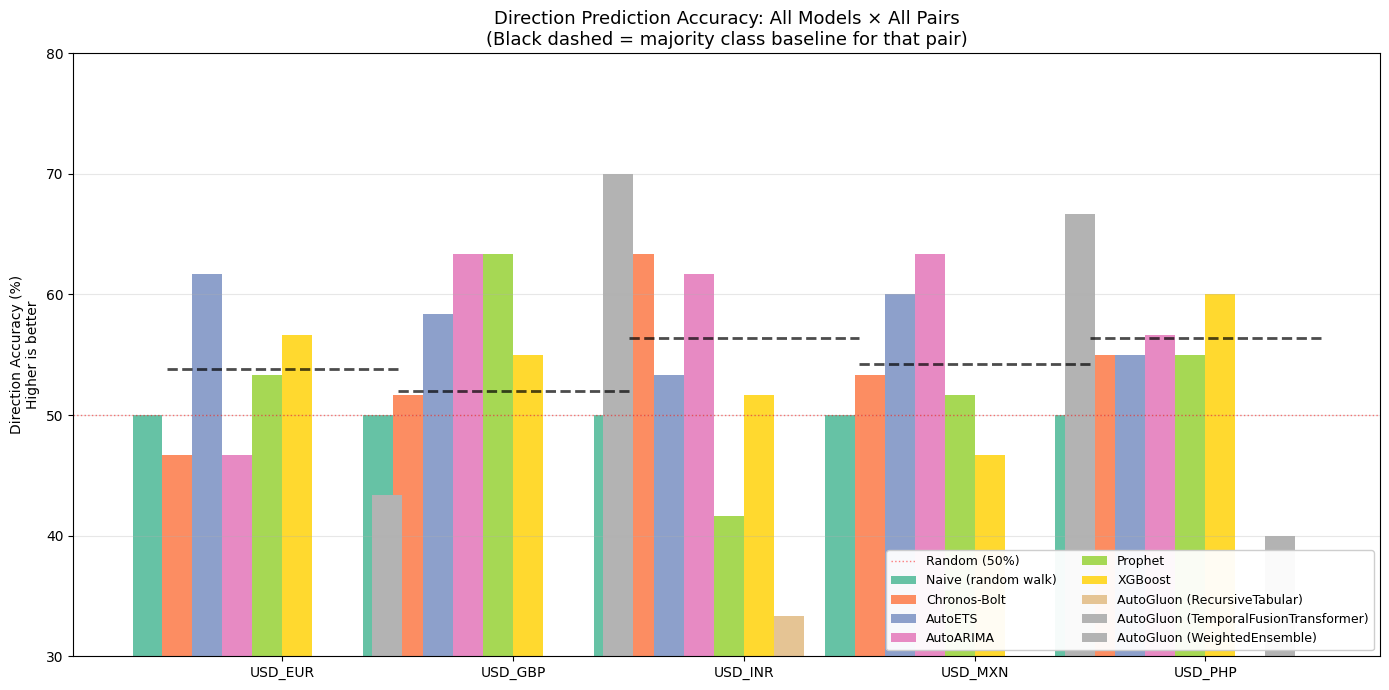

Note: bars must exceed BOTH the red 50% line AND the black majority-class line
to be considered genuinely useful.


In [4]:
direction_models = master_df.dropna(subset=['direction_acc']).copy()

majority_baselines = {
    'USD_INR': 56.4,
    'USD_EUR': 53.8,
    'USD_GBP': 52.0,
    'USD_MXN': 54.2,
    'USD_PHP': 56.4
}

pivot_dir = direction_models.pivot_table(index='model', columns='pair', values='direction_acc', aggfunc='first')

model_order = ['Naive (random walk)', 'Chronos-Bolt', 'AutoETS', 'AutoARIMA', 'Prophet', 'XGBoost']
ag_models = [m for m in pivot_dir.index if 'AutoGluon' in m]
model_order = [m for m in model_order if m in pivot_dir.index] + ag_models

pivot_dir = pivot_dir.reindex([m for m in model_order if m in pivot_dir.index])

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(pivot_dir.columns))
width = 0.13
colors = plt.cm.Set2(np.linspace(0, 1, len(pivot_dir)))

for i, (model, row) in enumerate(pivot_dir.iterrows()):
    offset = (i - len(pivot_dir)/2) * width
    bars = ax.bar(x + offset, row.values, width, label=model, color=colors[i])

# Plot majority baseline as horizontal markers
for i, pair in enumerate(pivot_dir.columns):
    if pair in majority_baselines:
        baseline = majority_baselines[pair]
        ax.plot([i - 0.5, i + 0.5], [baseline, baseline], 'k--', linewidth=2, alpha=0.7)

ax.axhline(50, color='red', linestyle=':', linewidth=1, alpha=0.5, label='Random (50%)')
ax.set_xticks(x)
ax.set_xticklabels(pivot_dir.columns)
ax.set_ylabel('Direction Accuracy (%)\nHigher is better')
ax.set_title('Direction Prediction Accuracy: All Models × All Pairs\n(Black dashed = majority class baseline for that pair)', fontsize=13)
ax.legend(loc='lower right', fontsize=9, framealpha=0.95, ncol=2)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(30, 80)

plt.tight_layout()
plt.savefig('final_direction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Note: bars must exceed BOTH the red 50% line AND the black majority-class line")
print("to be considered genuinely useful.")

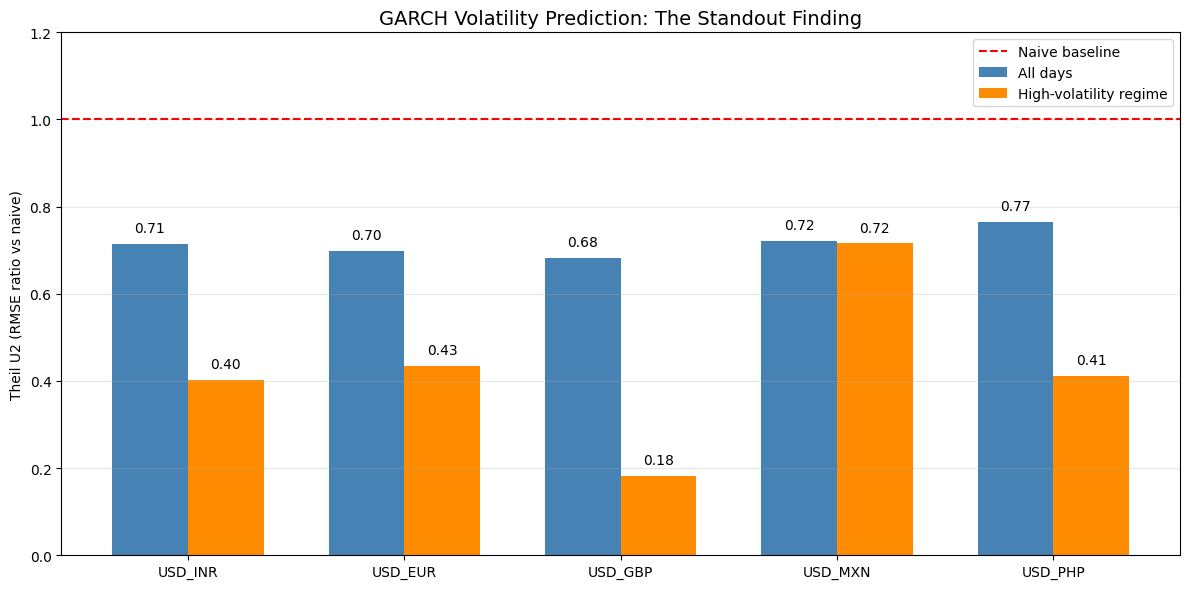

GARCH consistently beats naive baseline (all bars below red line).
In high-volatility regimes, the improvement is dramatic (50-80% reduction).


In [5]:
garch_data = []
for pair in pairs:
    if all_results['garch'] and pair in all_results['garch']:
        g = all_results['garch'][pair]
        garch_data.append({
            'pair': pair.upper(),
            'all_days': g['theil_u_vs_naive']
        })

# Add high-vol regime data from conditional analysis
if all_results['conditional']:
    cond = pd.DataFrame(all_results['conditional']['garch_volatility'])
    for pair_data in garch_data:
        high_vol = cond[(cond['pair'] == pair_data['pair']) & 
                        (cond['condition'] == 'GARCH high-vol forecast')]
        if not high_vol.empty:
            pair_data['high_vol_regime'] = high_vol['theil_u_naive'].iloc[0]

garch_df = pd.DataFrame(garch_data).set_index('pair')

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(garch_df))
width = 0.35

bars1 = ax.bar(x - width/2, garch_df['all_days'], width, label='All days', color='steelblue')
bars2 = ax.bar(x + width/2, garch_df['high_vol_regime'], width, label='High-volatility regime', color='darkorange')

ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Naive baseline')
ax.set_xticks(x)
ax.set_xticklabels(garch_df.index)
ax.set_ylabel('Theil U2 (RMSE ratio vs naive)')
ax.set_title('GARCH Volatility Prediction: The Standout Finding', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.02,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, 1.2)
plt.tight_layout()
plt.savefig('final_garch_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("GARCH consistently beats naive baseline (all bars below red line).")
print("In high-volatility regimes, the improvement is dramatic (50-80% reduction).")

In [6]:
print("=" * 70)
print("STATISTICAL SIGNIFICANCE SUMMARY — Direction Prediction")
print("=" * 70)

from scipy import stats

# Pull Chronos direction results
print("\n--- vs 50% Random Baseline ---\n")

if all_results['chronos']:
    for pair in pairs:
        if pair in all_results['chronos']:
            c = all_results['chronos'][pair]
            n = c['test_days']
            correct = int(c['direction_accuracy'] * n)
            p_random = 1 - stats.binom.cdf(correct - 1, n, 0.5)
            sig = "✓ SIGNIFICANT" if p_random < 0.05 else "✗ not significant"
            print(f"Chronos {pair.upper():<10}: {correct}/{n} = {correct/n*100:.1f}%  p={p_random:.4f}  {sig}")

print("\n--- vs Majority-Class Baseline (the harder test) ---\n")

if all_results['chronos']:
    for pair in pairs:
        if pair in all_results['chronos']:
            c = all_results['chronos'][pair]
            n = c['test_days']
            correct = int(c['direction_accuracy'] * n)
            maj = majority_baselines.get(pair.upper(), 50) / 100
            p_majority = 1 - stats.binom.cdf(correct - 1, n, maj)
            sig = "✓ beats majority" if p_majority < 0.05 else "✗ ties or loses to majority"
            print(f"Chronos {pair.upper():<10}: {correct/n*100:.1f}% vs {maj*100:.1f}% majority  p={p_majority:.4f}  {sig}")

print("\n--- Honest Conclusion ---")
print("Multiple models beat 50% random baseline, but NO model significantly")
print("beats the majority-class baseline (the meaningful comparison).")
print("This is consistent with Meese-Rogoff finding for daily FX prediction.")

STATISTICAL SIGNIFICANCE SUMMARY — Direction Prediction

--- vs 50% Random Baseline ---

Chronos USD_INR   : 38/60 = 63.3%  p=0.0259  ✓ SIGNIFICANT
Chronos USD_EUR   : 28/60 = 46.7%  p=0.7405  ✗ not significant
Chronos USD_GBP   : 31/60 = 51.7%  p=0.4487  ✗ not significant
Chronos USD_MXN   : 32/60 = 53.3%  p=0.3494  ✗ not significant
Chronos USD_PHP   : 33/60 = 55.0%  p=0.2595  ✗ not significant

--- vs Majority-Class Baseline (the harder test) ---

Chronos USD_INR   : 63.3% vs 56.4% majority  p=0.1705  ✗ ties or loses to majority
Chronos USD_EUR   : 46.7% vs 53.8% majority  p=0.8919  ✗ ties or loses to majority
Chronos USD_GBP   : 51.7% vs 52.0% majority  p=0.5723  ✗ ties or loses to majority
Chronos USD_MXN   : 53.3% vs 54.2% majority  p=0.6054  ✗ ties or loses to majority
Chronos USD_PHP   : 55.0% vs 56.4% majority  p=0.6381  ✗ ties or loses to majority

--- Honest Conclusion ---
Multiple models beat 50% random baseline, but NO model significantly
beats the majority-class baseline 

In [7]:
print("=" * 70)
print("PRODUCTION STACK — FINAL DECISIONS")
print("=" * 70)

decisions = pd.DataFrame([
    {
        'Component': 'Bollinger Bands (EWMA)',
        'Decision': '✅ DEPLOY',
        'Use Case': 'Context signal — all pairs',
        'Evidence': 'Stable, well-understood, EWMA beats SMA for trending pairs'
    },
    {
        'Component': 'Chronos-Bolt',
        'Decision': '✅ DEPLOY (selective)',
        'Use Case': 'Direction for USD/INR + USD/PHP (around events)',
        'Evidence': 'INR: 63% (p=0.026), well-calibrated 80% intervals'
    },
    {
        'Component': 'GARCH(1,1) Student-t',
        'Decision': '✅ DEPLOY',
        'Use Case': 'Volatility for all pairs',
        'Evidence': 'Theil U 0.68-0.77 overall, 0.18-0.44 in high-vol regimes'
    },
    {
        'Component': 'Prophet',
        'Decision': '❌ REJECTED',
        'Use Case': 'N/A',
        'Evidence': 'Theil U 2.1-3.7 — catastrophically worse than naive'
    },
    {
        'Component': 'XGBoost',
        'Decision': '❌ REJECTED',
        'Use Case': 'N/A',
        'Evidence': 'No improvement over majority baseline on any pair'
    },
    {
        'Component': 'AutoARIMA / AutoETS',
        'Decision': '❌ REJECTED',
        'Use Case': 'N/A',
        'Evidence': 'Predictions degenerate to trivial trend-following'
    },
    {
        'Component': 'AutoGluon ensemble',
        'Decision': '❌ REJECTED',
        'Use Case': 'N/A',
        'Evidence': 'Multi-step Theil 1.3-4.1, no improvement on existing stack'
    },
])

print(decisions.to_string(index=False))

PRODUCTION STACK — FINAL DECISIONS
             Component             Decision                                        Use Case                                                   Evidence
Bollinger Bands (EWMA)             ✅ DEPLOY                      Context signal — all pairs Stable, well-understood, EWMA beats SMA for trending pairs
          Chronos-Bolt ✅ DEPLOY (selective) Direction for USD/INR + USD/PHP (around events)          INR: 63% (p=0.026), well-calibrated 80% intervals
  GARCH(1,1) Student-t             ✅ DEPLOY                        Volatility for all pairs   Theil U 0.68-0.77 overall, 0.18-0.44 in high-vol regimes
               Prophet           ❌ REJECTED                                             N/A        Theil U 2.1-3.7 — catastrophically worse than naive
               XGBoost           ❌ REJECTED                                             N/A          No improvement over majority baseline on any pair
   AutoARIMA / AutoETS           ❌ REJECTED                

In [8]:
print("=" * 70)
print("CONDITIONAL FINDINGS — When Each Model Works Best")
print("=" * 70)

print("""
DIRECTION PREDICTION (Chronos-Bolt):
  - USD/INR around central bank events: 69% (vs 63% all days)  [+6pp]
  - USD/PHP around central bank events: 69% (vs 55% all days)  [+14pp]
  - Pattern is suggestive but not statistically significant (n=13 per pair)
  - Calibration consistent across regimes (80% intervals contain 73-89% of outcomes)
  
  Product implication: increase confidence in direction signals
  during ±2 day windows around FOMC/RBI/BSP meetings.

VOLATILITY PREDICTION (GARCH):
  - All pairs in high-volatility regimes: Theil U 0.18-0.72 vs naive
  - USD/GBP high-vol: Theil U 0.18 (82% improvement) — strongest result
  - USD/MXN exception: no improvement in high-vol (likely Banxico intervention)
  - Performance scales with volatility — most accurate when most actionable
  
  Product implication: GARCH volatility signals are trustworthy and
  should drive urgency framing ("lock in now" vs "you can wait").

CALIBRATION:
  - Chronos 80% intervals: 73-89% coverage across all regimes
  - Most consistent finding in the project
  
  Product implication: probability bands can be surfaced to users
  without regime-specific warnings or caveats.
""")

CONDITIONAL FINDINGS — When Each Model Works Best

DIRECTION PREDICTION (Chronos-Bolt):
  - USD/INR around central bank events: 69% (vs 63% all days)  [+6pp]
  - USD/PHP around central bank events: 69% (vs 55% all days)  [+14pp]
  - Pattern is suggestive but not statistically significant (n=13 per pair)
  - Calibration consistent across regimes (80% intervals contain 73-89% of outcomes)

  Product implication: increase confidence in direction signals
  during ±2 day windows around FOMC/RBI/BSP meetings.

VOLATILITY PREDICTION (GARCH):
  - All pairs in high-volatility regimes: Theil U 0.18-0.72 vs naive
  - USD/GBP high-vol: Theil U 0.18 (82% improvement) — strongest result
  - USD/MXN exception: no improvement in high-vol (likely Banxico intervention)
  - Performance scales with volatility — most accurate when most actionable

  Product implication: GARCH volatility signals are trustworthy and
  should drive urgency framing ("lock in now" vs "you can wait").

CALIBRATION:
  - Chronos 8

In [9]:
print("=" * 70)
print("FX-ADVISOR PROJECT — EXECUTIVE SUMMARY")
print("=" * 70)

print("""
PROJECT OVERVIEW
  Built an end-to-end FX transfer advisor on AWS, combining:
  1. Production data pipeline (Lambda + S3 + Glue + Athena + DynamoDB + SES)
  2. Daily automated forecasting and email signal generation
  3. Comprehensive forecasting model comparison (7+ approaches tested)
  4. Statistical evaluation framework with proper Theil's U2 methodology

KEY FINDINGS

  1. Daily FX direction is fundamentally near-random (Meese-Rogoff confirmed)
     No model significantly beats majority-class baseline on any pair.
     
  2. Foundation models (Chronos-Bolt) provide best honest predictions
     - 63% direction accuracy on USD/INR (statistically significant vs random)
     - Well-calibrated probability intervals (77-87% coverage at 80% target)
     - Outperforms classical models on probabilistic forecasting
     
  3. Multi-step forecasting is dramatically harder than single-step
     AutoGluon's best models achieve Theil U 1.3-4.1 on 30-day forecasts,
     vs Theil U ~1.0 on 1-day forecasts. Implication: focus on near-term.
     
  4. GARCH volatility prediction is the strongest, most robust finding
     - 23-32% RMSE reduction vs naive across all pairs
     - 56-82% reduction in high-volatility regimes
     - This is what powers actionable "lock in now vs wait" recommendations
     
  5. Event-window direction prediction shows promising pattern
     Chronos accuracy on trending pairs (INR, PHP) increases around 
     central bank meetings by 6-14 percentage points.
     Suggestive but requires more data to confirm statistically.

PRODUCTION STACK
  ✅ Bollinger Bands (EWMA)    Context signal, all pairs
  ✅ Chronos-Bolt              Direction (USD/INR, USD/PHP) — selective
  ✅ GARCH(1,1)                Volatility — all pairs
  
REJECTED (with documented evidence)
  ❌ Prophet                  Theil U 2-4x worse than naive
  ❌ XGBoost                  No improvement over majority baseline  
  ❌ AutoARIMA/ETS            Degenerate to trivial trend-following
  ❌ AutoGluon ensembles      Multi-step performance worse than naive

METHODOLOGICAL RIGOR
  - Proper Theil's U2 (RMSE-based, not MAE) across all comparisons
  - Statistical significance testing vs both random AND majority baselines
  - Walk-forward evaluation (60-day rolling test) for valid comparisons
  - Prediction distribution analysis to detect trivial trend-following
  - Calibration analysis for probabilistic forecasts
  - Conditional evaluation by regime (events, volatility)

TECHNICAL STACK
  Infrastructure: AWS Lambda, S3, Glue, Athena, DynamoDB, EventBridge, SES
  Modeling:       Python, Chronos, GARCH (arch), Prophet, XGBoost, AutoGluon
  Data sources:   Frankfurter API (FX), FRED (US macro), BIS (foreign rates)
  Visualization:  matplotlib, pandas

REPOSITORY
  github.com/ninadparab/fx-advisor
""")

FX-ADVISOR PROJECT — EXECUTIVE SUMMARY

PROJECT OVERVIEW
  Built an end-to-end FX transfer advisor on AWS, combining:
  1. Production data pipeline (Lambda + S3 + Glue + Athena + DynamoDB + SES)
  2. Daily automated forecasting and email signal generation
  3. Comprehensive forecasting model comparison (7+ approaches tested)
  4. Statistical evaluation framework with proper Theil's U2 methodology

KEY FINDINGS

  1. Daily FX direction is fundamentally near-random (Meese-Rogoff confirmed)
     No model significantly beats majority-class baseline on any pair.

  2. Foundation models (Chronos-Bolt) provide best honest predictions
     - 63% direction accuracy on USD/INR (statistically significant vs random)
     - Well-calibrated probability intervals (77-87% coverage at 80% target)
     - Outperforms classical models on probabilistic forecasting

  3. Multi-step forecasting is dramatically harder than single-step
     AutoGluon's best models achieve Theil U 1.3-4.1 on 30-day forecasts,
 

In [10]:
# Save the master comparison dataframe for reference
master_df.to_csv('final_model_comparison.csv', index=False)

print("Final comparison saved to final_model_comparison.csv")
print("\nProject complete.")
print("Next steps for production deployment:")
print("  1. Update fx-compute-signal Lambda to use EWMA Bollinger Bands")
print("  2. Add GARCH volatility forecast to daily signal pipeline")
print("  3. Add Chronos-Bolt direction signal (USD/INR + USD/PHP only)")
print("  4. Add event-aware confidence adjustment around central bank meetings")
print("  5. Update email template with three-layer recommendation logic")

Final comparison saved to final_model_comparison.csv

Project complete.
Next steps for production deployment:
  1. Update fx-compute-signal Lambda to use EWMA Bollinger Bands
  2. Add GARCH volatility forecast to daily signal pipeline
  3. Add Chronos-Bolt direction signal (USD/INR + USD/PHP only)
  4. Add event-aware confidence adjustment around central bank meetings
  5. Update email template with three-layer recommendation logic
